# Data Visualization Practice

This is my own practice notebook based on what I learned in the IBM Data Analyst Capstone Project on Coursera.

This notebook practices loading survey data, creating a SQLite database, running basic SQL queries, and creating several data visualizations using pandas and matplotlib.

## 1. Download the survey dataset

The dataset is downloaded as a CSV file so it can be loaded into pandas and then inserted into a SQLite database.

In [1]:
# Download the survey dataset
!wget -O survey-data.csv "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

--2026-06-14 19:11:46--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... 

connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M   621KB/s    in 6m 29s  

2026-06-14 19:18:17 (401 KB/s) - ‘survey-data.csv’ saved [159525875/159525875]



## 2. Import required libraries

In [2]:
# Import libraries used in this notebook
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## 3. Read the CSV file into a pandas dataframe

In [3]:
# Read the CSV file into a pandas dataframe
df = pd.read_csv('survey-data.csv')

# Display the first five rows to confirm the data loaded correctly
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## 4. Create a SQLite database and insert the data

The dataframe is saved into a SQLite database table called `main`.

In [4]:
# Create a connection to a SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to a SQL table called main
# if_exists='replace' recreates the table if it already exists
# index=False avoids saving the dataframe index as an extra column
df.to_sql('main', conn, if_exists='replace', index=False)

# Close the connection after inserting the data
conn.close()

## 5. Verify the data in the SQLite database

In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Select the first five rows from the main table
QUERY = "SELECT * FROM main LIMIT 5"

# Run the SQL query and store the result in a dataframe
df_check = pd.read_sql_query(QUERY, conn)

# Display the result
df_check

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,None,None
3,4,I am learning to code,18-24 years old,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,None,None
4,5,I am a developer by profession,18-24 years old,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,None,None


## 6. Run a SQL query to count rows

In [6]:
# Count the number of rows in the main table
QUERY = """
SELECT COUNT(*)
FROM main
"""

# Run the query and display the result
pd.read_sql_query(QUERY, conn)

,COUNT(*)
0,65437


## 7. List all tables in the database

In [7]:
# List all table names in the SQLite database
QUERY = """
SELECT name AS Table_Name
FROM sqlite_master
WHERE type = 'table'
"""

# Run the query and display the result
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


## 8. Run a GROUP BY query

This query counts how many respondents are in each age group.

In [8]:
# Group respondents by Age and count each group
QUERY = """
SELECT Age, COUNT(*) AS count
FROM main
GROUP BY Age
ORDER BY Age
"""

# Run the query and display the result
pd.read_sql_query(QUERY, conn)

,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## 9. Describe the main table schema

In [9]:
# Store the table name
table_name = 'main'

# Get the SQL statement used to create the table
QUERY = """
SELECT sql
FROM sqlite_master
WHERE name = '{}'
""".format(table_name)

# Run the query
df_schema = pd.read_sql_query(QUERY, conn)

# Print the schema
print(df_schema.iat[0, 0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## 10. Histogram: distribution of `CompTotal`

Extreme `CompTotal` values are excluded from the displayed range because they make the histogram unreadable.

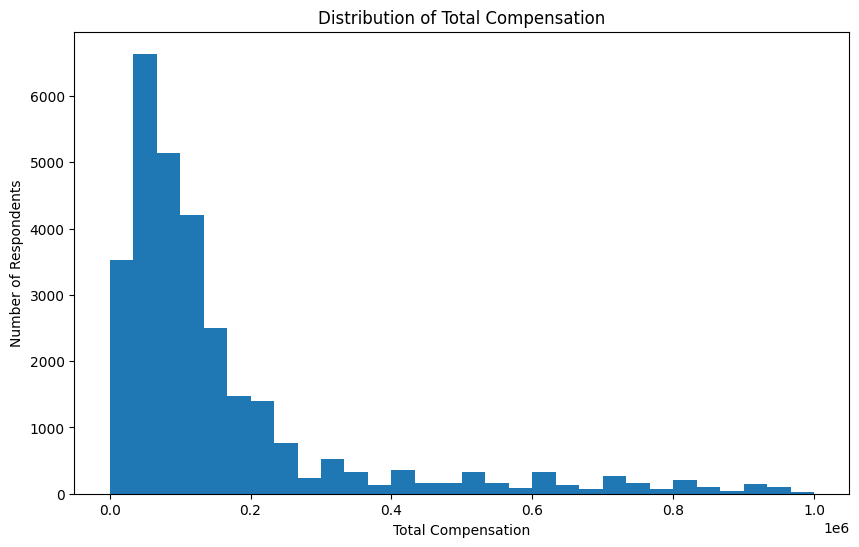

In [10]:
# Select CompTotal and remove missing values
comp_total = df['CompTotal'].dropna()

# Keep a readable compensation range for visualization
comp_total_readable = comp_total[comp_total < 1_000_000]

# Plot histogram of CompTotal
plt.figure(figsize=(10, 6))
plt.hist(comp_total_readable, bins=30)

plt.title('Distribution of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.show()

## 11. Box plot: age distribution

The `Age` column is categorical, so age groups are mapped to approximate numeric values before plotting.

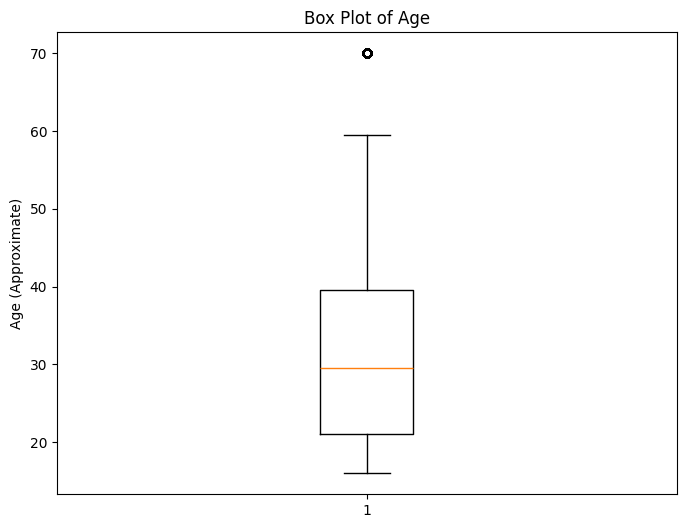

In [11]:
# Define a mapping of age ranges to numeric midpoints
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

# Create a separate dataframe for age plotting
df_age_clean = df[['Age']].copy()

# Convert age ranges to approximate numeric values
df_age_clean['Age_numeric'] = df_age_clean['Age'].map(age_mapping)

# Drop missing or unmapped age values
df_age_clean = df_age_clean.dropna(subset=['Age_numeric'])

# Plot the box plot
plt.figure(figsize=(8, 6))
plt.boxplot(df_age_clean['Age_numeric'], vert=True)

plt.title('Box Plot of Age')
plt.ylabel('Age (Approximate)')
plt.show()

## 12. Scatter plot: age vs work experience

The `Age` column is categorical, so age groups are mapped to approximate numeric values before plotting against `WorkExp`.

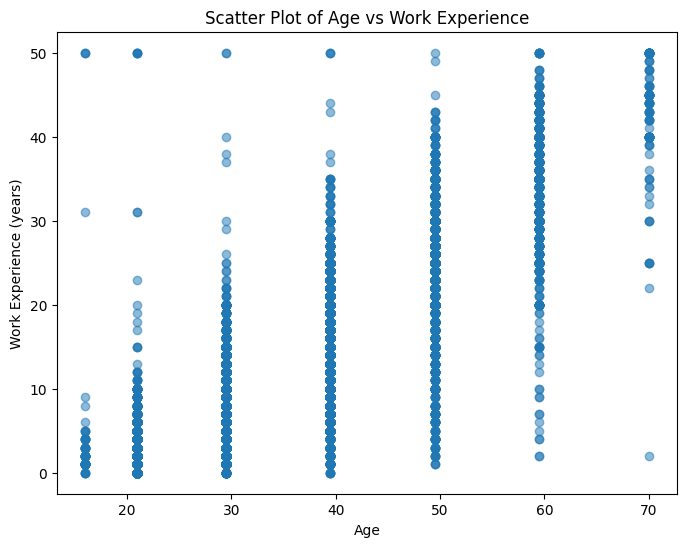

In [12]:
# Define a mapping of age ranges to numeric midpoints
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}

# Create a separate dataframe for the scatter plot
df_scatter = df[['Age', 'WorkExp']].copy()

# Convert age ranges to approximate numeric values
df_scatter['Age_numeric'] = df_scatter['Age'].map(age_mapping)

# Remove rows with missing Age_numeric or WorkExp
df_scatter = df_scatter.dropna(subset=['Age_numeric', 'WorkExp'])

# Create scatter plot of Age and Work Experience
plt.figure(figsize=(8, 6))
plt.scatter(df_scatter['Age_numeric'], df_scatter['WorkExp'], alpha=0.5)

plt.title('Scatter Plot of Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience (years)')
plt.show()

## 13. Bubble plot: time searching vs frustration

This bubble plot uses `TimeSearching` and `Frustration`, with approximate age values used as bubble size. The chart is limited because the selected columns are categorical.

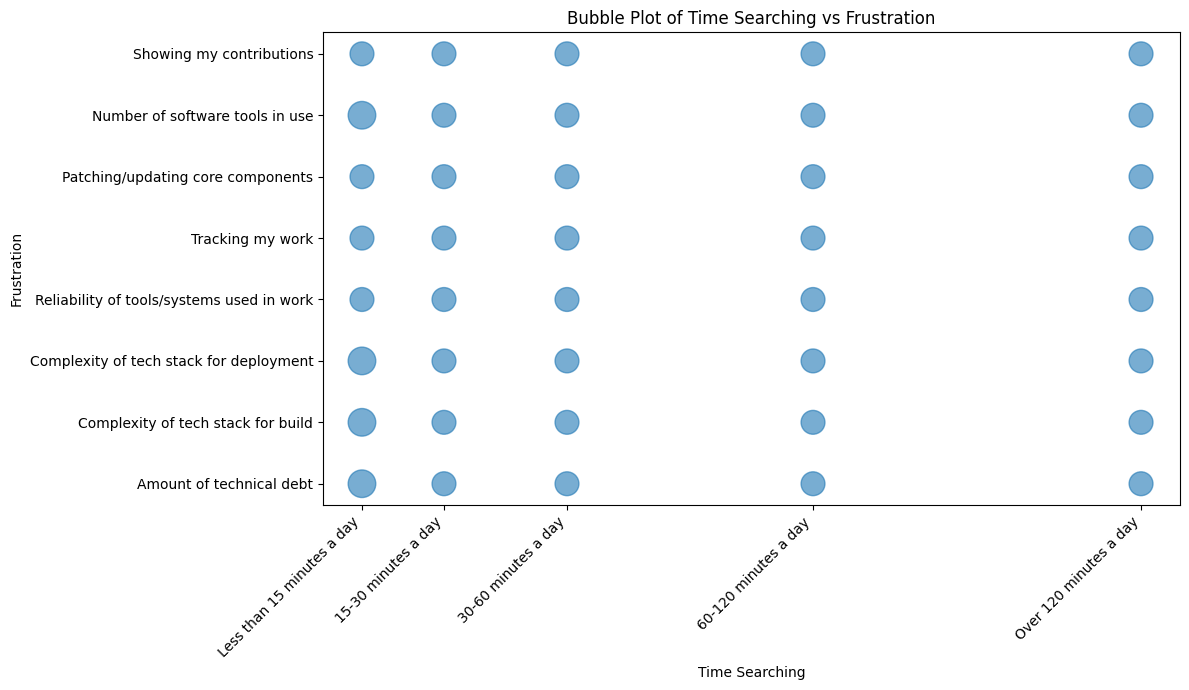

In [13]:
# Create a separate dataframe for the bubble plot
df_bubble = df[['TimeSearching', 'Frustration', 'Age']].copy()

# Convert Age groups into numeric values for bubble size
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}

df_bubble['Age_numeric'] = df_bubble['Age'].map(age_mapping)

# Convert TimeSearching categories into approximate minutes
time_mapping = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

df_bubble['Time_minutes'] = df_bubble['TimeSearching'].map(time_mapping)

# Remove missing values
df_bubble = df_bubble.dropna(subset=['Time_minutes', 'Frustration', 'Age_numeric'])

# Split multiple frustration answers into separate rows
df_bubble['Frustration'] = df_bubble['Frustration'].str.split(';')
df_bubble = df_bubble.explode('Frustration')
df_bubble['Frustration'] = df_bubble['Frustration'].str.strip()

# Keep only the top 8 frustrations so the chart stays readable
top_frustrations = df_bubble['Frustration'].value_counts().head(8).index
df_bubble = df_bubble[df_bubble['Frustration'].isin(top_frustrations)]

# Create one row per TimeSearching and Frustration combination
bubble_data = df_bubble.groupby(
    ['Time_minutes', 'TimeSearching', 'Frustration'],
    as_index=False
)['Age_numeric'].median()

# Convert frustration labels into numeric positions for plotting
frustration_order = list(top_frustrations)
frustration_mapping = {value: index for index, value in enumerate(frustration_order)}
bubble_data['Frustration_position'] = bubble_data['Frustration'].map(frustration_mapping)

# Create bubble plot
plt.figure(figsize=(12, 7))
plt.scatter(
    bubble_data['Time_minutes'],
    bubble_data['Frustration_position'],
    s=bubble_data['Age_numeric'] * 10,
    alpha=0.6
)

plt.title('Bubble Plot of Time Searching vs Frustration')
plt.xlabel('Time Searching')
plt.ylabel('Frustration')

plt.xticks(
    list(time_mapping.values()),
    list(time_mapping.keys()),
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(frustration_order)),
    frustration_order
)

plt.tight_layout()
plt.show()

## 14. Pie chart: top 5 databases respondents want to work with

Multiple database answers are split so each database mention can be counted separately.

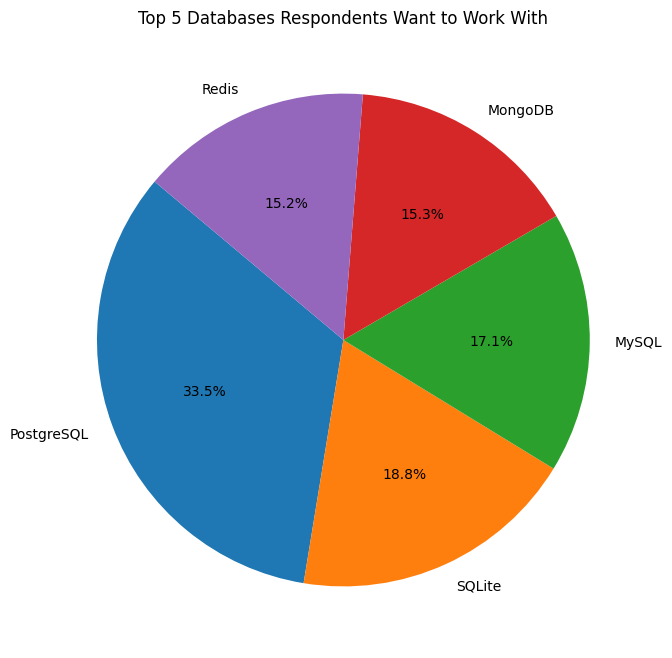

In [14]:
# Drop rows with missing values in the database column
df_db = df['DatabaseWantToWorkWith'].dropna()

# Split multiple database answers into separate rows
all_dbs = df_db.str.split(';').explode()

# Count each database
db_counts = all_dbs.value_counts()

# Select the top 5 databases
top5_dbs = db_counts.head(5)

# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    top5_dbs,
    labels=top5_dbs.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Databases Respondents Want to Work With')
plt.show()

## 15. Stacked bar chart: median time searching and answering

The dataset does not contain an exact 30-35 age group, so `25-34 years old` is used as the closest available proxy.

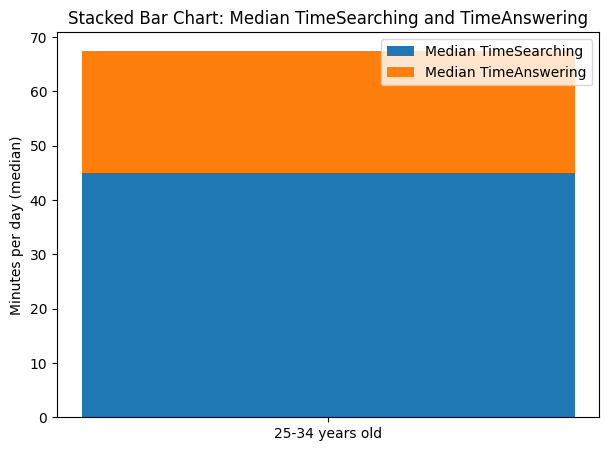

In [15]:
# The dataset does not have an exact 30-35 age group.
# The closest available age bucket is 25-34 years old.
target_age_bucket = '25-34 years old'

# Convert time categories into approximate minutes
time_map = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

# Create a separate dataframe for this chart
df_stack = df[['Age', 'TimeSearching', 'TimeAnswering']].copy()

# Convert TimeSearching and TimeAnswering into numeric minutes
df_stack['TimeSearching_min'] = df_stack['TimeSearching'].map(time_map)
df_stack['TimeAnswering_min'] = df_stack['TimeAnswering'].map(time_map)

# Filter to the closest age bucket and remove missing values
df_stack_age = df_stack[
    df_stack['Age'] == target_age_bucket
].dropna(subset=['TimeSearching_min', 'TimeAnswering_min'])

# Calculate median values
median_search = df_stack_age['TimeSearching_min'].median()
median_answer = df_stack_age['TimeAnswering_min'].median()

# Create stacked bar chart
plt.figure(figsize=(7, 5))
plt.bar(target_age_bucket, median_search, label='Median TimeSearching')
plt.bar(target_age_bucket, median_answer, bottom=median_search, label='Median TimeAnswering')

plt.title('Stacked Bar Chart: Median TimeSearching and TimeAnswering')
plt.ylabel('Minutes per day (median)')
plt.legend()
plt.show()

## 16. Line chart: median `CompTotal` for age groups 45 to 60

The dataset has age buckets, not exact ages, so the closest available age-group midpoints are used.

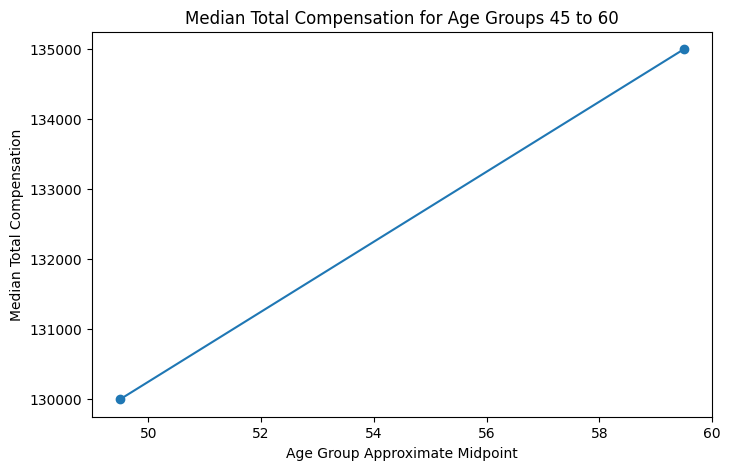

In [16]:
# The dataset has age buckets, not exact ages.
# We use the closest available buckets for ages 45 to 60.
age_map = {
    '45-54 years old': 49.5,
    '55-64 years old': 59.5
}

# Create a separate dataframe for the line chart
df_line = df[['Age', 'CompTotal']].copy()

# Convert selected age groups to approximate numeric midpoints
df_line['Age_num'] = df_line['Age'].map(age_map)

# Keep only selected age groups and valid compensation values
df_line = df_line.dropna(subset=['Age_num', 'CompTotal'])

# Calculate median CompTotal by age midpoint
median_comp = df_line.groupby('Age_num')['CompTotal'].median().reset_index()

# Create line chart
plt.figure(figsize=(8, 5))
plt.plot(median_comp['Age_num'], median_comp['CompTotal'], marker='o')

plt.title('Median Total Compensation for Age Groups 45 to 60')
plt.xlabel('Age Group Approximate Midpoint')
plt.ylabel('Median Total Compensation')
plt.show()

## 17. Horizontal bar chart: `MainBranch`

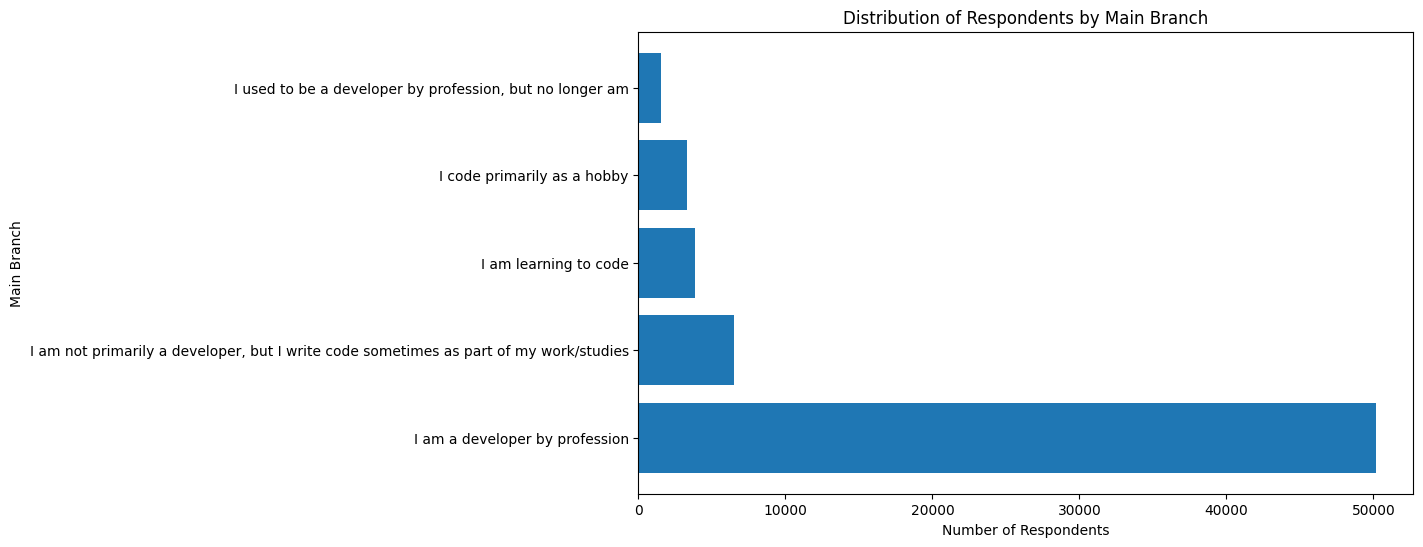

In [17]:
# Count occurrences of each MainBranch category
branch_counts = df['MainBranch'].value_counts()

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(branch_counts.index, branch_counts.values)

plt.title('Distribution of Respondents by Main Branch')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch')
plt.show()

## 18. Close the database connection

In [18]:
# Close the SQLite database connection
conn.close()

## Summary

This notebook practiced:

- downloading and loading survey data
- creating a SQLite database
- running basic SQL queries
- creating histograms, box plots, scatter plots, bubble plots, pie charts, stacked bar charts, line charts, and bar charts
- using safe temporary dataframes for chart-specific transformations

Important note: several columns in this dataset are categorical text, so approximate mappings were used for some visualizations.